# Exploratory Data Analysis — Indian Mutual Fund Holdings

Before the SQL analysis and the dashboard, this notebook explores the scraped dataset with
pandas: data quality, distributions, the fund overlap matrix, sector tilts and concentration.

Dataset: 45 top Indian equity mutual funds (by AUM) across 5 categories, scraped from
Moneycontrol in Feb-Mar 2026. One row = one stock holding of one fund.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Blues_r")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/mutual_fund_holdings_dashboard.csv")
print(df.shape)
df.head()

(3421, 6)


,fund_name,stock_name,sector,holding_pct,market_cap,fund_category
0,ICICI Prudential Large Cap Fund,ICICI Bank Ltd.,Private sector bank,9.42,Large Cap,Large Cap
1,ICICI Prudential Large Cap Fund,HDFC Bank Ltd.,Private sector bank,9.16,Other,Large Cap
2,ICICI Prudential Large Cap Fund,Larsen & Toubro Ltd.,Civil construction,6.34,Large Cap,Large Cap
3,ICICI Prudential Large Cap Fund,Reliance Industries Ltd.,Refineries & marketing,5.98,Large Cap,Large Cap
4,ICICI Prudential Large Cap Fund,Axis Bank Ltd.,Private sector bank,4.61,Large Cap,Large Cap


## 1. Data quality

Checks before trusting any downstream number: nulls, duplicates, dtypes, and whether
each fund's equity weights add up to something sensible (should be near 100%, lower is
fine since debt/cash holdings are excluded).

In [2]:
print("nulls per column:")
print(df.isna().sum())
print("\nduplicate fund+stock rows:", df.duplicated(subset=["fund_name", "stock_name"]).sum())
print("funds:", df.fund_name.nunique(), "| unique stocks:", df.stock_name.nunique(),
      "| sectors:", df.sector.nunique())
df.describe()

nulls per column:
fund_name        0
stock_name       0
sector           0
holding_pct      0
market_cap       0
fund_category    0
dtype: int64

duplicate fund+stock rows: 0
funds: 45 | unique stocks: 827 | sectors: 160


,holding_pct
count,3421.000000
mean,1.257188
std,1.424395
min,0.000000
25%,0.410000
50%,0.860000
75%,1.540000
max,14.070000


lowest coverage funds:
fund_name
Parag Parikh Flexi Cap Fund    78.4
SBI Small Cap Fund             86.0
Bandhan Small Cap Fund         89.8


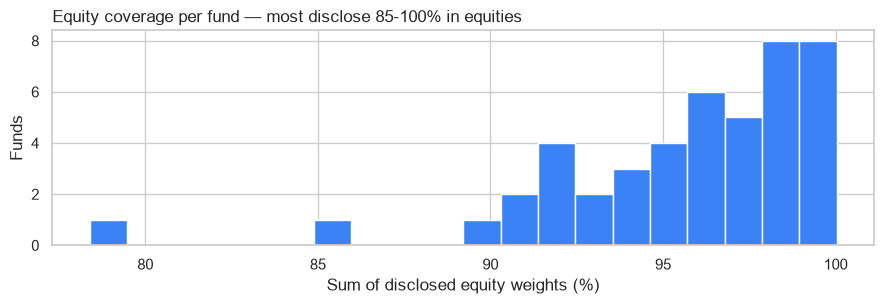

In [3]:
coverage = df.groupby("fund_name").holding_pct.sum().sort_values()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(coverage, bins=20, color="#3b82f6", edgecolor="white")
ax.set_xlabel("Sum of disclosed equity weights (%)")
ax.set_ylabel("Funds")
ax.set_title("Equity coverage per fund — most disclose 85-100% in equities", loc="left")
plt.tight_layout()
print("lowest coverage funds:")
print(coverage.head(3).round(1).to_string())

## 2. How many stocks does a fund actually hold?

Category structure shows up immediately: index funds hold exactly their benchmark,
small caps cast a wide net.

,min,median,max
fund_category,,,
Index,30,50.0,50
Large Cap,45,60.5,79
Flexi Cap,23,63.5,78
Mid Cap,26,71.5,99
Small Cap,67,97.0,245


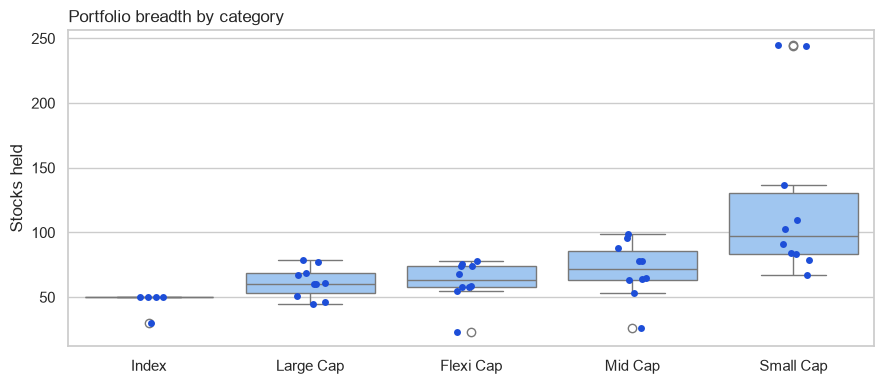

In [4]:
order = ["Index", "Large Cap", "Flexi Cap", "Mid Cap", "Small Cap"]
counts = df.groupby(["fund_category", "fund_name"]).size().reset_index(name="n_stocks")
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=counts, x="fund_category", y="n_stocks", order=order, color="#93c5fd", ax=ax)
sns.stripplot(data=counts, x="fund_category", y="n_stocks", order=order,
              color="#1d4ed8", size=5, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Stocks held")
ax.set_title("Portfolio breadth by category", loc="left")
plt.tight_layout()
counts.groupby("fund_category").n_stocks.agg(["min", "median", "max"]).loc[order]

## 3. Holding weights — a long-tail distribution

Most positions are tiny; conviction bets above 5% are rare and concentrated in
large cap and index funds.

median position: 0.86% | positions above 5%: 98


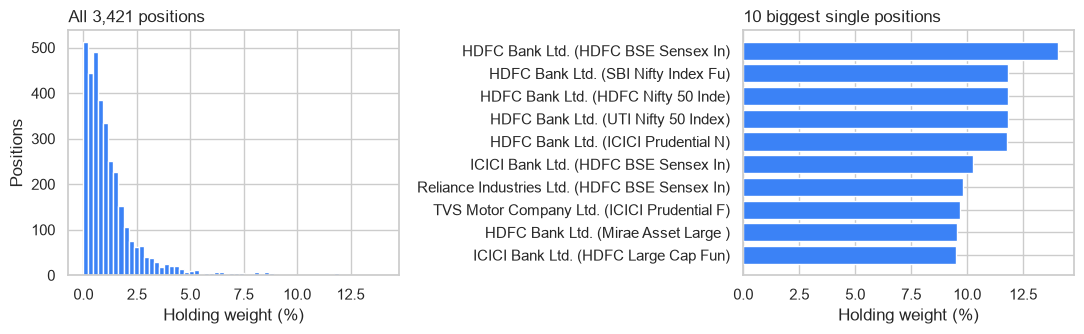

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df.holding_pct, bins=60, color="#3b82f6", edgecolor="white")
axes[0].set_xlabel("Holding weight (%)"); axes[0].set_ylabel("Positions")
axes[0].set_title("All 3,421 positions", loc="left")

top = df.sort_values("holding_pct", ascending=False).head(10)
axes[1].barh(top.stock_name + " (" + top.fund_name.str.slice(0, 18) + ")",
             top.holding_pct, color="#3b82f6")
axes[1].invert_yaxis()
axes[1].set_xlabel("Holding weight (%)")
axes[1].set_title("10 biggest single positions", loc="left")
plt.tight_layout()
print(f"median position: {df.holding_pct.median():.2f}% | positions above 5%: {(df.holding_pct > 5).sum()}")

## 4. Stock popularity — the crowding problem

If every fund holds the same names, holding several funds diversifies nothing.
This is the core question the whole project hangs on.

287 of 827 stocks (35%) are held by exactly one fund


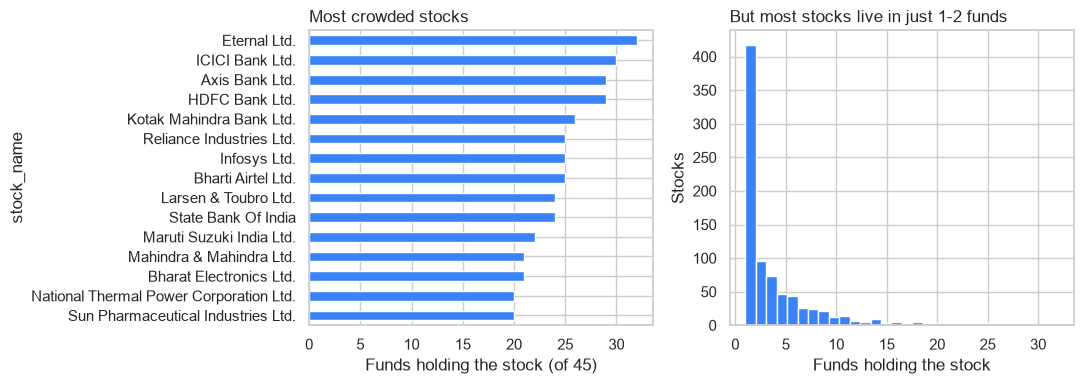

In [6]:
popularity = df.groupby("stock_name").fund_name.nunique().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
popularity.head(15).sort_values().plot.barh(ax=axes[0], color="#3b82f6")
axes[0].set_xlabel("Funds holding the stock (of 45)")
axes[0].set_title("Most crowded stocks", loc="left")

axes[1].hist(popularity, bins=30, color="#3b82f6", edgecolor="white")
axes[1].set_xlabel("Funds holding the stock"); axes[1].set_ylabel("Stocks")
axes[1].set_title("But most stocks live in just 1-2 funds", loc="left")
plt.tight_layout()
print(f"{(popularity == 1).sum()} of {len(popularity)} stocks ({(popularity == 1).mean():.0%}) are held by exactly one fund")

## 5. The overlap matrix

Weighted overlap between two funds = sum over common stocks of min(weight A, weight B).
Computed here in pandas for all 45x45 fund pairs (the SQL notebook derives the same
metric with self-joins).

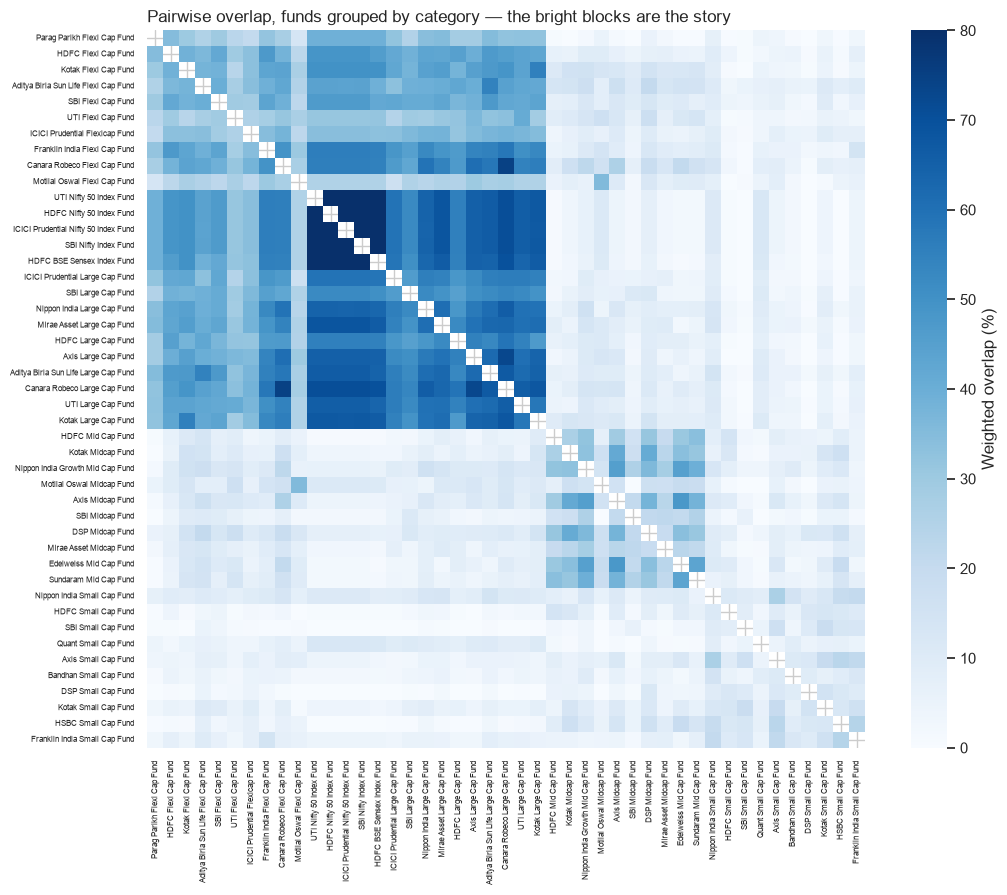

In [7]:
w = df.pivot_table(index="fund_name", columns="stock_name",
                   values="holding_pct", aggfunc="sum", fill_value=0)
# min(a, b) summed over stocks, vectorized: (a + b - |a - b|) / 2
A = w.to_numpy()
overlap = (A[:, None, :] + A[None, :, :] - np.abs(A[:, None, :] - A[None, :, :])).sum(axis=2) / 2
overlap_df = pd.DataFrame(overlap, index=w.index, columns=w.index)

cat = df.drop_duplicates("fund_name").set_index("fund_name").fund_category
fund_order = cat.sort_values(kind="stable").index
o = overlap_df.loc[fund_order, fund_order]
mask = np.eye(len(o), dtype=bool)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(o, mask=mask, cmap="Blues", vmax=80, square=True,
            cbar_kws={"label": "Weighted overlap (%)"},
            xticklabels=True, yticklabels=True, ax=ax)
ax.tick_params(labelsize=6)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title("Pairwise overlap, funds grouped by category — the bright blocks are the story",
             loc="left")
plt.tight_layout()

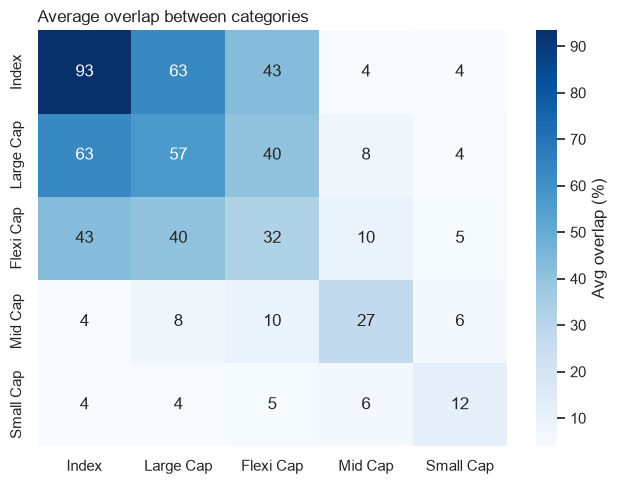

In [8]:
pairs = (overlap_df.rename_axis(index="fund_a", columns="fund_b")
         .where(~np.eye(len(overlap_df), dtype=bool))
         .stack().rename("overlap").reset_index())
pairs["cat_a"] = pairs.fund_a.map(cat); pairs["cat_b"] = pairs.fund_b.map(cat)
cat_overlap = pairs.pivot_table(index="cat_a", columns="cat_b", values="overlap").loc[order, order]
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(cat_overlap, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "Avg overlap (%)"}, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title("Average overlap between categories", loc="left")
plt.tight_layout()

## 6. Sector tilts by category

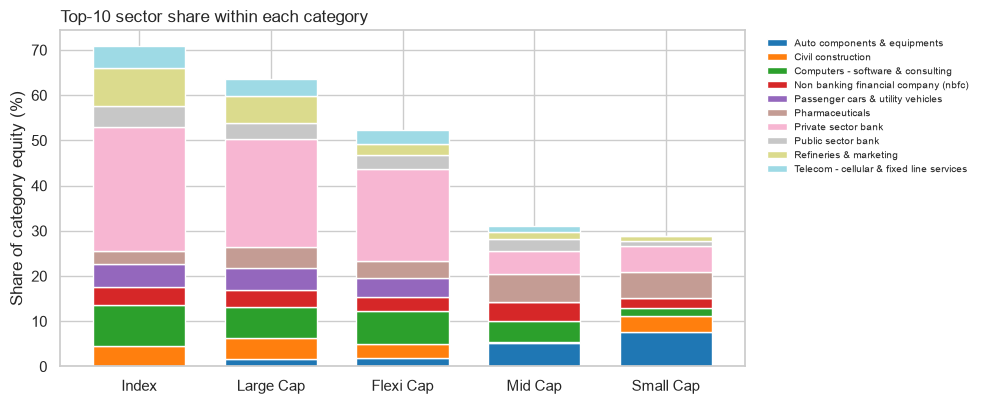

In [9]:
top_sectors = df.groupby("sector").holding_pct.sum().nlargest(10).index
sect = (df[df.sector.isin(top_sectors)]
        .pivot_table(index="fund_category", columns="sector",
                     values="holding_pct", aggfunc="sum"))
sect = sect.div(df.groupby("fund_category").holding_pct.sum(), axis=0).loc[order] * 100
fig, ax = plt.subplots(figsize=(10, 4.2))
sect.plot.bar(stacked=True, ax=ax, colormap="tab20", width=0.7)
ax.set_ylabel("Share of category equity (%)"); ax.set_xlabel("")
ax.set_title("Top-10 sector share within each category", loc="left")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()

## 7. Market-cap mix — what are you actually buying?

The category label on the box doesn't fully describe the contents. Index funds carry
zero small-cap exposure, and "Flexi" cap funds tilt heavily toward large caps.

market_cap,Large Cap,Mid Cap,Small Cap,Other
fund_category,,,,
Index,70.5,3.7,NaN,25.8
Large Cap,64.3,7.2,1.8,26.8
Flexi Cap,46.6,12.4,6.2,34.8
Mid Cap,11.7,40.2,15.2,32.8
Small Cap,5.0,11.3,44.8,38.9


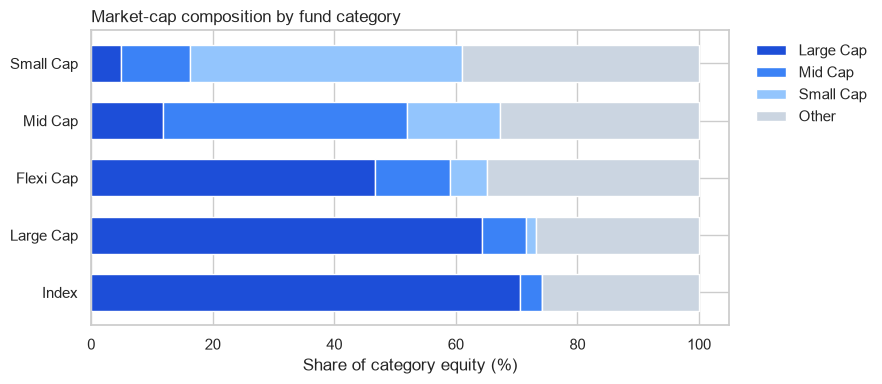

In [10]:
cap_order = ["Large Cap", "Mid Cap", "Small Cap", "Other"]
cap_mix = (df.pivot_table(index="fund_category", columns="market_cap",
                          values="holding_pct", aggfunc="sum")
             .div(df.groupby("fund_category").holding_pct.sum(), axis=0)
             .reindex(columns=cap_order).loc[order] * 100)
fig, ax = plt.subplots(figsize=(9, 4))
cap_mix.plot.barh(stacked=True, ax=ax,
                  color=["#1d4ed8", "#3b82f6", "#93c5fd", "#cbd5e1"], width=0.65)
ax.set_xlabel("Share of category equity (%)"); ax.set_ylabel("")
ax.set_title("Market-cap composition by fund category", loc="left")
ax.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
cap_mix.round(1)

## 8. Which funds are the most (and least) unique?

Average overlap of each fund against the other 44 — the funds at the bottom are the
ones that actually add something different to a portfolio.

most unique funds:
fund_name
Quant Small Cap Fund      6.3
Bandhan Small Cap Fund    5.0
HDFC Small Cap Fund       4.7
DSP Small Cap Fund        3.7
SBI Small Cap Fund        3.3


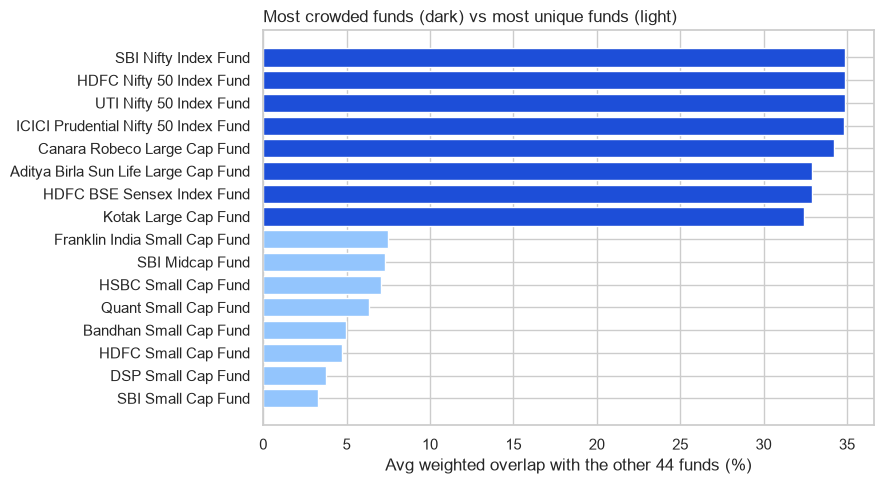

In [11]:
avg_overlap = (overlap_df.where(~np.eye(len(overlap_df), dtype=bool))
               .mean(axis=1).sort_values(ascending=False))
uniq = pd.concat([avg_overlap.head(8), avg_overlap.tail(8)])
colors = ["#1d4ed8"] * 8 + ["#93c5fd"] * 8
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(uniq.index, uniq.values, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Avg weighted overlap with the other 44 funds (%)")
ax.set_title("Most crowded funds (dark) vs most unique funds (light)", loc="left")
plt.tight_layout()
print("most unique funds:")
print(avg_overlap.tail(5).round(1).to_string())

## 9. Does holding more stocks mean more diversification?

Not necessarily — the scatter shows funds holding 60+ stocks while still parking
40%+ of the portfolio in their top 5 bets.

,fund_name,n_stocks,top5_weight
10,HDFC BSE Sensex Index Fund,30,44.85
11,HDFC Nifty 50 Index Fund,50,37.55
13,SBI Nifty Index Fund,50,37.55


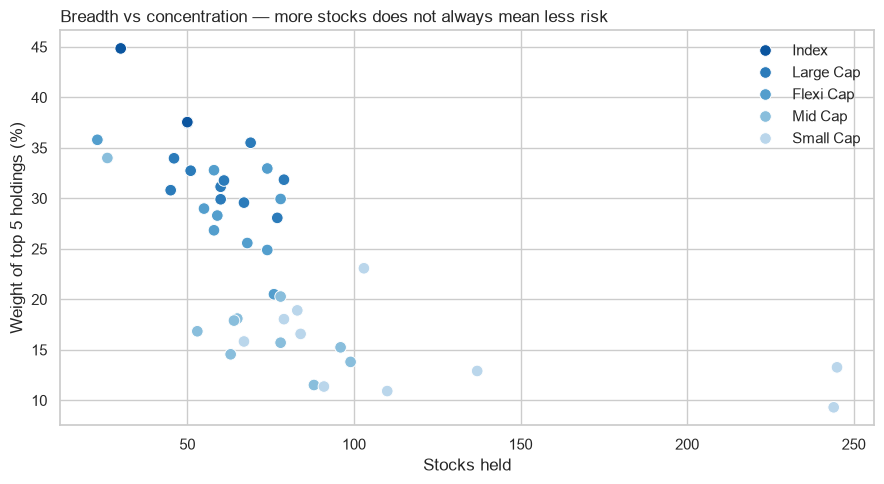

In [12]:
top5 = (df.sort_values("holding_pct", ascending=False)
          .groupby("fund_name").head(5)
          .groupby("fund_name").holding_pct.sum())
stats = counts.set_index("fund_name").join(top5.rename("top5_weight"))
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=stats.reset_index(), x="n_stocks", y="top5_weight",
                hue="fund_category", hue_order=order, s=70, ax=ax)
ax.set_xlabel("Stocks held"); ax.set_ylabel("Weight of top 5 holdings (%)")
ax.set_title("Breadth vs concentration — more stocks does not always mean less risk",
             loc="left")
ax.legend(title="", frameon=False)
plt.tight_layout()
stats.reset_index().nlargest(3, "top5_weight")[["fund_name", "n_stocks", "top5_weight"]]

## Takeaways

1. Data is clean: no nulls, no duplicate fund+stock pairs, equity coverage 85-100% for
   most funds — the exclusions are debt/cash, as expected.
2. **Crowding is real but asymmetric**: a handful of banks appear in 30 of 45 funds,
   yet ~60% of stocks are held by exactly one fund. Overlap is a large-cap phenomenon.
3. The category-level overlap heatmap confirms the diversification recipe: mixing
   across categories (especially Small + Large) cuts overlap to single digits, while
   stacking same-category funds duplicates 50-100% of the portfolio.
4. The label on the box misleads: index funds have zero small-cap exposure, and
   Flexi Cap funds hold far more large cap than small.
5. Uniqueness ranking backs the crowding story from the other side — index and large
   cap funds are interchangeable, while a few funds (foreign holdings, deep small cap)
   genuinely add something different.
6. Breadth is not diversification — several wide funds still concentrate 40%+ in five names.

The SQL notebook (`mutual_fund_overlap_analysis.ipynb`) drills into these findings with
19 queries, and the Power BI dashboard makes them explorable per fund.